In [10]:
#필요한 라이브러리를 로드합니다.
import os
import math
import numpy as np
import torch
import torchvision.transforms as transforms

from PIL import Image
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from glob import glob

import torch.nn as nn
import torch.optim as optim

In [11]:
import torch
import numpy as np
import PIL
import skimage
import albumentations

print(torch.__version__)
print(np.__version__)
print(PIL.__version__)
print(skimage.__version__)
print(albumentations.__version__)

2.7.1+cu118
2.2.6
11.2.1
0.25.2
2.0.8


In [12]:
from albumentations import  HorizontalFlip, RandomSizedCrop, Compose, OneOf, Resize

def build_augmentation(is_train=True):
  if is_train:    # 훈련용 데이터일 경우
    return Compose([
                    HorizontalFlip(p=0.5),    # 50%의 확률로 좌우대칭
                    RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop
                        min_max_height=(300, 370),
                        w2h_ratio=370/1242,
                        height=224,
                        width=224,
                        size=(224, 224),
                        p=0.5
                        ),
                    Resize(              # 입력이미지를 224X224로 resize
                        width=224,
                        height=224
                        )
                    ])
  return Compose([      # 테스트용 데이터일 경우에는 224X224로 resize만 수행합니다.
                Resize(
                    width=224,
                    height=224
                    )
                ])

/tmp/ipykernel_92/2497950994.py:7: UserWarning: Argument(s) 'height, width' are not valid for transform RandomSizedCrop
  RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop


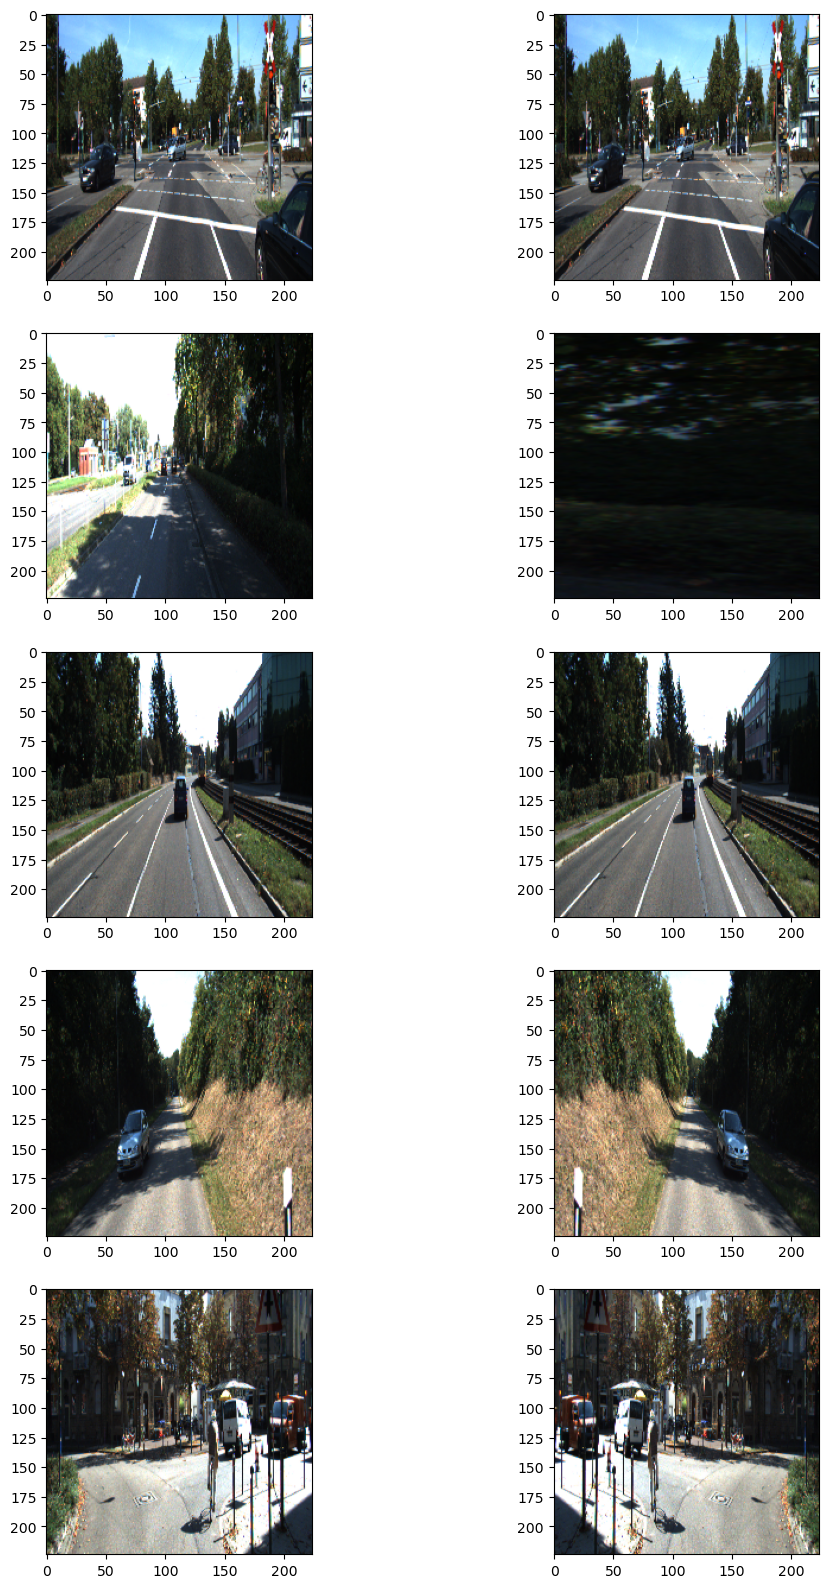

In [13]:
data_dir = os.path.join(os.getenv("HOME"), "work/semantic_segmentation/data/training")

augmentation_train = build_augmentation()
augmentation_test = build_augmentation(is_train=False)
input_images = glob(os.path.join(data_dir, "image_2", "*.png"))

# 훈련 데이터셋에서 5개만 가져와 augmentation을 적용해 봅시다.
plt.figure(figsize=(12, 20))
for i in range(5):
    image = imread(input_images[i])
    image_data = {"image":image}
    resized = augmentation_test(**image_data)
    processed = augmentation_train(**image_data)
    plt.subplot(5, 2, 2*i+1)
    plt.imshow(resized["image"])  # 왼쪽이 원본이미지
    plt.subplot(5, 2, 2*i+2)
    plt.imshow(processed["image"])  # 오른쪽이 augment된 이미지

plt.show()

In [14]:
from glob import glob
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from imageio.v2 import imread

class KittiDataset(Dataset):
    def __init__(self,
                 dir_path,
                 img_size=(224, 224, 3),
                 output_size=(224, 224),
                 is_train=True,
                 augmentation=None,
                 use_full=False):          # ★ 추가: 전체 데이터로 평가할 때 True
        self.dir_path = dir_path
        self.is_train = is_train
        self.augmentation = augmentation
        self.img_size = img_size
        self.output_size = output_size
        self.use_full = use_full        # ★ 저장

        self.data = self.load_dataset()

    def load_dataset(self):
        input_images = sorted(glob(os.path.join(self.dir_path, "image_2", "*.png")))
        label_images = sorted(glob(os.path.join(self.dir_path, "semantic", "*.png")))
        assert len(input_images) == len(label_images)
        data = list(zip(input_images, label_images))

        # ★ 전체 데이터 평가 모드면 슬라이싱 없이 모두 반환
        if self.use_full:
            return data

        # 기존 로직 유지 (학습/테스트 30장 분리)
        if self.is_train:
            return data[:-30]
        return data[-30:]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        input_img_path, output_path = self.data[index]
        _input = imread(input_img_path)
        _output = imread(output_path)

        # road 라벨을 이진으로 (필요시 값 변경)
        _output = (_output == 7).astype(np.uint8) * 1

        data = {"image": _input, "mask": _output}

        if self.augmentation:
            augmented = self.augmentation(**data)
            _input = augmented["image"] / 255.0
            _output = augmented["mask"]

        _output = np.expand_dims(_output, axis=0)
        return (
            torch.tensor(_input, dtype=torch.float32).permute(2, 0, 1),
            torch.tensor(_output, dtype=torch.float32)
        )

    def shuffle_data(self):
        if self.is_train:
            np.random.shuffle(self.data)


In [15]:
from torch.utils.data import DataLoader

augmentation = build_augmentation()
test_preproc = build_augmentation(is_train=False)

# 학습/부분 테스트 (기존과 동일)
train_dataset = KittiDataset(data_dir, augmentation=augmentation,  is_train=True,  use_full=False)
test_dataset  = KittiDataset(data_dir, augmentation=test_preproc, is_train=False, use_full=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

# 🔥 두 모델 비교용: "전체 데이터" 평가 로더
full_eval_dataset = KittiDataset(data_dir, augmentation=test_preproc, is_train=False, use_full=True)
full_eval_loader  = DataLoader(full_eval_dataset, batch_size=2, shuffle=False)  # 배치는 메모리 상황에 맞춰 조절


/tmp/ipykernel_92/2497950994.py:7: UserWarning: Argument(s) 'height, width' are not valid for transform RandomSizedCrop
  RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop


In [16]:
# =========================
# ① 모델 정의: UNet++
# =========================
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Tuple, List, Optional

class ConvBlock(nn.Module):
    """ℋ(·): Conv(+BN)+ReLU × 2"""
    def __init__(self, in_ch: int, out_ch: int, use_bn: bool = True, act_layer=nn.ReLU):
        super().__init__()
        bias = not use_bn
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=bias),
        ]
        if use_bn: layers += [nn.BatchNorm2d(out_ch)]
        layers += [act_layer(inplace=True),
                   nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=bias)]
        if use_bn: layers += [nn.BatchNorm2d(out_ch)]
        layers += [act_layer(inplace=True)]
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class UpSampler(nn.Module):
    """
    U(·): 한 단계 업샘플
    - mode='bilinear': 파라미터 없음(채널 유지)
    - mode='transpose': ConvTranspose2d(채널 변경 가능)
    """
    def __init__(self, in_ch: int, out_ch: int, mode: str = "transpose"):
        super().__init__()
        self.mode = mode
        if mode == "transpose":
            self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        elif mode == "bilinear":
            assert in_ch == out_ch, "bilinear는 채널을 유지해야 합니다 (in_ch==out_ch)."
            self.up = None
        else:
            raise ValueError("mode must be 'bilinear' or 'transpose'")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.mode == "bilinear":
            return F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        return self.up(x)


class UNetPP(nn.Module):
    """
    U-Net++ (Nested U-Net)
    - filters: 고해상도→저해상도 채널 (len = D+1)
    - up_mode: 'transpose' 또는 'bilinear'
    - deep_supervision=False (기본) — 마지막 노드 x[0,D]에서 로짓 1×1 Conv
    """
    def __init__(
        self,
        in_ch: int = 3,
        out_ch: int = 1,
        filters: Tuple[int, ...] = (64, 128, 256, 512, 1024),
        up_mode: str = "transpose",
        use_bn: bool = True,
        deep_supervision: bool = False,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.filters = filters
        self.D = len(filters) - 1
        self.up_mode = up_mode
        self.deep_supervision = deep_supervision

        # ----- Encoder: x[i,0] -----
        self.enc_blocks = nn.ModuleList()
        self.pools = nn.ModuleList()
        self.enc_blocks.append(ConvBlock(in_ch, filters[0], use_bn))
        for i in range(1, self.D + 1):
            self.pools.append(nn.MaxPool2d(2))
            self.enc_blocks.append(ConvBlock(filters[i - 1], filters[i], use_bn))
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        # ----- Up-samplers: (i+1) → i -----
        self.up = nn.ModuleList()
        self.up_out_ch: List[int] = []
        for i in range(self.D):  # 0..D-1
            if up_mode == 'bilinear':
                up_out = filters[i + 1]
            else:  # transpose
                up_out = filters[i]
            self.up_out_ch.append(up_out)
            self.up.append(UpSampler(filters[i + 1], up_out, up_mode))

        # ----- Decoder convs: x[i,j] = ℋ([x[i,0..j-1], U(x[i+1,j-1])]) -----
        self.dec_blocks = nn.ModuleDict()
        for i in range(0, self.D):            # 마지막 행은 디코더 없음
            for j in range(1, self.D - i + 1):  # j=1..(D-i)
                in_ch_ij = j * filters[i] + self.up_out_ch[i]
                self.dec_blocks[f"conv_{i}_{j}"] = ConvBlock(in_ch_ij, filters[i], use_bn)

        # ----- Heads -----
        if deep_supervision:
            self.side_heads = nn.ModuleList([
                nn.Conv2d(filters[0], out_ch, kernel_size=1) for _ in range(1, self.D + 1)
            ])
        else:
            self.head = nn.Conv2d(filters[0], out_ch, kernel_size=1)

    def _dec(self, i: int, j: int) -> ConvBlock:
        return self.dec_blocks[f"conv_{i}_{j}"]

    def forward(self, x: torch.Tensor):
        # 격자 컨테이너 X[i][j]
        X: List[List[Optional[torch.Tensor]]] = [[None]*(self.D+1) for _ in range(self.D+1)]

        # ----- Encoder pass -----
        X[0][0] = self.enc_blocks[0](x)
        for i in range(1, self.D + 1):
            X[i][0] = self.enc_blocks[i](self.pools[i - 1](X[i - 1][0]))
        X[self.D][0] = self.dropout(X[self.D][0])  # bottleneck dropout

        # ----- Nested decoder -----
        for j in range(1, self.D + 1):
            for i in range(0, self.D - j + 1):
                up_feat = self.up[i](X[i + 1][j - 1])
                cat_feats = [X[i][k] for k in range(0, j)] + [up_feat]
                X[i][j] = self._dec(i, j)(torch.cat(cat_feats, dim=1))

        # ----- Heads -----
        if self.deep_supervision:
            outs = []
            for j in range(1, self.D + 1):
                outs.append(self.side_heads[j - 1](X[0][j]))  # 로짓들 리스트
            return outs
        else:
            return self.head(X[0][self.D])  # 로짓 하나 (sigmoid는 밖에서)


In [8]:
# =========================
# ② 학습 코드
# =========================
import os, torch, numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# (이미 데이터셋이 준비돼 있다고 가정)
# train_dataset, test_dataset 가 존재해야 합니다.

# --- 손실: BCEWithLogits + Dice ---
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):  # logits:[B,1,H,W], targets:[B,1,H,W] 0/1
        probs = torch.sigmoid(logits)
        targets = targets.float()
        probs = probs.flatten(1)
        targets = targets.flatten(1)
        inter = (probs * targets).sum(1)
        union = probs.sum(1) + targets.sum(1)
        dice = (2*inter + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.w = bce_weight
    def forward(self, logits, targets):
        return self.w * self.bce(logits, targets.float()) + (1-self.w) * self.dice(logits, targets)

# --- 디바이스/모델/옵티마이저 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNetPP(
    in_ch=3, out_ch=1,
    filters=(32, 64, 128, 256, 512),   # ★ 변경: 채널 절반
    up_mode='transpose',
    use_bn=True,
    deep_supervision=False,
    dropout=0.5
).to(device)

criterion = BCEDiceLoss(bce_weight=0.5)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# --- 데이터로더 ---
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  # ★ 변경: 16 → 4
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False, # ★ 변경: 16 → 4
                          num_workers=2, pin_memory=True)

# --- 학습 루프 ---
num_epochs = 100
model_path = "seg_model_unetpp.pth"

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for inputs, targets in train_loader:
        inputs = inputs.to(device)  # [B,3,H,W]
        # targets shape 보정: [B,H,W] -> [B,1,H,W]
        if targets.dim() == 3:
            targets = targets.unsqueeze(1)
        targets = targets.to(device)  # [B,1,H,W], 0/1

        optimizer.zero_grad()
        outputs = model(inputs)  # logits
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / max(1, len(train_loader))
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f}")

# --- 저장 ---
torch.save(model.state_dict(), model_path)

# --- 로드(예: CPU 추론용) ---
infer_model = UNetPP(
    in_ch=3, out_ch=1,
    filters=(32, 64, 128, 256, 512),   # ★ 변경 동일
    up_mode='transpose',
    use_bn=True,
    deep_supervision=False,
    dropout=0.0
)
infer_model.load_state_dict(torch.load(model_path, map_location='cpu'))
infer_model.eval()


Epoch 1/100 | Loss: 0.5734
Epoch 2/100 | Loss: 0.4967
Epoch 3/100 | Loss: 0.4320
Epoch 4/100 | Loss: 0.4298
Epoch 5/100 | Loss: 0.4113
Epoch 6/100 | Loss: 0.3967
Epoch 7/100 | Loss: 0.4060
Epoch 8/100 | Loss: 0.3896
Epoch 9/100 | Loss: 0.3774
Epoch 10/100 | Loss: 0.3710
Epoch 11/100 | Loss: 0.3903
Epoch 12/100 | Loss: 0.3708
Epoch 13/100 | Loss: 0.3710
Epoch 14/100 | Loss: 0.3533
Epoch 15/100 | Loss: 0.3311
Epoch 16/100 | Loss: 0.3599
Epoch 17/100 | Loss: 0.3345
Epoch 18/100 | Loss: 0.3273
Epoch 19/100 | Loss: 0.3273
Epoch 20/100 | Loss: 0.3040
Epoch 21/100 | Loss: 0.3064
Epoch 22/100 | Loss: 0.2930
Epoch 23/100 | Loss: 0.3083
Epoch 24/100 | Loss: 0.2798
Epoch 25/100 | Loss: 0.3100
Epoch 26/100 | Loss: 0.3037
Epoch 27/100 | Loss: 0.2949
Epoch 28/100 | Loss: 0.3009
Epoch 29/100 | Loss: 0.2868
Epoch 30/100 | Loss: 0.2786
Epoch 31/100 | Loss: 0.2773
Epoch 32/100 | Loss: 0.2780
Epoch 33/100 | Loss: 0.2725
Epoch 34/100 | Loss: 0.2787
Epoch 35/100 | Loss: 0.2559
Epoch 36/100 | Loss: 0.2602
E

UNetPP(
  (enc_blocks): ModuleList(
    (0): ConvBlock(
      (net): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (net): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=Tru

In [6]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 69.4 MB/s eta 0:00:00:00:0100:01


In [17]:
# =========================
# ③ 시각화 / IoU 평가 코드
# =========================
import numpy as np, cv2, os
from PIL import Image
import matplotlib.pyplot as plt
from imageio.v2 import imread  # 없으면: from matplotlib.pyplot import imread

@torch.no_grad()
def get_output(model, preproc, image_path, output_path, label_path=None, device='cpu', thr=0.5):
    """
    model: logits 반환(UNetPP)
    preproc: {'image': np.uint8 HWC} -> {'image': np.uint8 or float HWC} 형태를 돌려주는 전처리 함수/객체
    """
    # ---- 원본 로드 & 전처리 ----
    origin_img = imread(image_path)  # HWC, uint8
    data = {"image": origin_img}
    processed = preproc(**data)      # {'image': ...}
    img = processed["image"]
    if img.dtype != np.float32:
        img = img.astype(np.float32) / 255.0
    input_tensor = torch.from_numpy(img).permute(2,0,1).unsqueeze(0).to(device)  # [1,3,H,W]

    # ---- 추론 ----
    model.eval()
    out = model(input_tensor)
    logits = out[-1] if isinstance(out, (list, tuple)) else out  # deep supervision 대응
    prob = torch.sigmoid(logits)[0,0].cpu().numpy()              # [H,W]
    pred_bin = (prob > thr).astype(np.uint8) * 255

    # ---- 리사이즈 (NEAREST) ----
    H, W = origin_img.shape[:2]
    pred_resized = cv2.resize(pred_bin, (W, H), interpolation=cv2.INTER_NEAREST)

    # ---- Overlay 시각화 ----
    background = Image.fromarray(origin_img).convert('RGBA')
    overlay = Image.fromarray(pred_resized).convert('RGBA')
    blended = Image.blend(background, overlay, alpha=0.5)
    blended.save(output_path)

    # ---- (선택) GT 로드 및 0/1 변환 ----
    target = None
    if label_path is not None:
        label_img = imread(label_path)
        # ★데이터셋에 맞게 road 라벨값을 0/1로 변환하세요.
        # 예시: Cityscapes trainId==0 이 road라면 (label_img==0). 여기선 임시로 (==7) 사용.
        target = (label_img == 7).astype(np.uint8)  # 필요 시 수정
        target = cv2.resize(target, (W, H), interpolation=cv2.INTER_NEAREST)

    # ---- show ----
    plt.imshow(np.array(blended)); plt.axis('off'); plt.show()
    return blended, pred_resized, target


def calculate_iou_score(target, prediction):
    """
    target, prediction: 0/1 or 0/255, H×W
    """
    if target is None:
        print("GT(target)가 없습니다. IoU 계산을 생략합니다.")
        return None

    target = (target > 0).astype(np.bool_)
    prediction = (prediction > 0).astype(np.bool_)
    if target.shape != prediction.shape:
        prediction = cv2.resize(prediction.astype(np.uint8), (target.shape[1], target.shape[0]),
                                interpolation=cv2.INTER_NEAREST).astype(bool)
    inter = np.logical_and(target, prediction).sum()
    union = np.logical_or(target, prediction).sum()
    iou = inter / (union + 1e-7)
    print(f"IoU : {iou:.6f}")
    return iou

In [19]:
dir_path = os.path.join(os.getenv("HOME"), "work/semantic_segmentation/data/training")
i = 26
blended, prediction, target = get_output(
    model=infer_model,           # 위에서 로드한 모델
    preproc=test_preproc,        # 이미 가지고 있는 전처리
    image_path=dir_path + f'/image_2/00{str(i).zfill(4)}_10.png',
    output_path=dir_path + f'/result_{str(i).zfill(3)}.png',
    label_path=dir_path + f'/semantic/00{str(i).zfill(4)}_10.png',  # 없으면 None
    device='cpu',
    thr=0.5
)
calculate_iou_score(target, prediction)


NameError: name 'infer_model' is not defined

# U-Net vs U-Net++

In [20]:
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, input_channels=3, output_channels=1):
        super(UNet, self).__init__()

        # Contracting Path (Encoder)
        self.enc1 = self.double_conv(input_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self.double_conv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = self.double_conv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = self.double_conv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = self.double_conv(512, 1024)
        self.dropout = nn.Dropout(0.5)

        # Expanding Path (Decoder)
        self.up6 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec6 = self.double_conv(1024, 512)
        self.up7 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec7 = self.double_conv(512, 256)
        self.up8 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec8 = self.double_conv(256, 128)
        self.up9 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec9 = self.double_conv(128, 64)

        # Output layer
        self.final = nn.Conv2d(64, output_channels, kernel_size=1)

    def double_conv(self, in_channels, out_channels):
        """2개의 Conv Layer로 이루어진 블록"""
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        c1 = self.enc1(x)
        p1 = self.pool1(c1)
        c2 = self.enc2(p1)
        p2 = self.pool2(c2)
        c3 = self.enc3(p2)
        p3 = self.pool3(c3)
        c4 = self.enc4(p3)
        p4 = self.pool4(c4)

        # Bottleneck
        c5 = self.bottleneck(p4)
        c5 = self.dropout(c5)

        # Decoder
        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        c6 = self.dec6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        c7 = self.dec7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        c8 = self.dec8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, c1], dim=1)
        c9 = self.dec9(u9)

        # Output
        output = torch.sigmoid(self.final(c9))
        return output

In [21]:
# --- 모델 로드
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# U-Net
unet = UNet(input_channels=3, output_channels=1).to(device)
unet.load_state_dict(torch.load("seg_model_unet.pth", map_location=device))
unet.eval()

# U-Net++  
unetpp = UNetPP(
    in_ch=3, out_ch=1,
    filters=(32,64,128,256,512),
    up_mode='transpose',
    use_bn=True,
    deep_supervision=False,
    dropout=0.0
).to(device)
unetpp.load_state_dict(torch.load("seg_model_unetpp.pth", map_location=device))
unetpp.eval()


UNetPP(
  (enc_blocks): ModuleList(
    (0): ConvBlock(
      (net): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (net): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=Tru

In [22]:
import torch
import numpy as np

@torch.no_grad()
def evaluate_model_iou_stats(model, dataloader, device, returns_logits: bool, thr: float = 0.5, use_sample_std: bool = False):
    """
    returns_logits:
      - U-Net: False (출력=확률)
      - U-Net++: True (출력=로짓 → 내부에서 sigmoid 적용)
    """
    model.eval()
    ious = []

    for imgs, gts in dataloader:
        imgs = imgs.to(device)

        # [B,H,W] or [B,1,H,W] -> [B,1,H,W], 0/1 float
        if gts.dim() == 3:
            gts = gts.unsqueeze(1)
        gts = (gts > 0).float().to(device)

        preds = model(imgs)
        if isinstance(preds, (list, tuple)):   # deep supervision 대응
            preds = preds[-1]

        if returns_logits:                      # UNet++ → 로짓 to 확률
            preds = torch.sigmoid(preds)

        preds_bin = (preds > thr).to(torch.bool)
        gts_bin   = (gts   > 0.5).to(torch.bool)

        # 배치 벡터화 IoU
        inter = (preds_bin & gts_bin).sum(dim=(1,2,3)).float()
        union = (preds_bin | gts_bin).sum(dim=(1,2,3)).float()
        iou   = (inter / (union + 1e-7)).cpu().numpy()  # [B]
        ious.extend(iou.tolist())

    ious = np.asarray(ious, dtype=np.float32)
    mean_iou = float(ious.mean()) if ious.size > 0 else 0.0
    std_iou  = float(ious.std(ddof=1 if use_sample_std else 0)) if ious.size > 1 else 0.0
    return {"mean": mean_iou, "std": std_iou, "n": int(ious.size), "ious": ious}

In [23]:
# UNet: returns_logits=False, UNet++: returns_logits=True
unet_stats   = evaluate_model_iou_stats(unet,   full_eval_loader, device, returns_logits=False, thr=0.5)
unetpp_stats = evaluate_model_iou_stats(unetpp, full_eval_loader, device, returns_logits=True,  thr=0.5)

print(f"[U-Net   ] mIoU = {unet_stats['mean']:.4f} ± {unet_stats['std']:.4f} (n={unet_stats['n']})")
print(f"[U-Net++] mIoU = {unetpp_stats['mean']:.4f} ± {unetpp_stats['std']:.4f} (n={unetpp_stats['n']})")
print(f"Δ mIoU (U-Net++ - U-Net) = {unetpp_stats['mean'] - unet_stats['mean']:+.4f}")

[U-Net   ] mIoU = 0.8275 ± 0.1373 (n=200)
[U-Net++] mIoU = 0.8742 ± 0.1164 (n=200)
Δ mIoU (U-Net++ - U-Net) = +0.0467


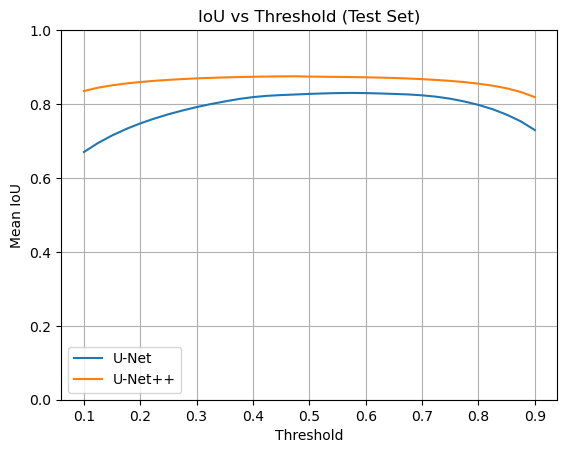

U-Net   best @thr=0.575, mIoU=0.8300
U-Net++ best @thr=0.475, mIoU=0.8751


In [25]:
import numpy as np
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def iou_stats_at_threshold(model, loader, device, returns_logits: bool, thr: float):
    """단일 threshold에서 mIoU와 표준편차 계산"""
    model.eval()
    ious = []

    for imgs, gts in loader:
        imgs = imgs.to(device)
        if gts.dim() == 3:
            gts = gts.unsqueeze(1)
        gts = (gts > 0).float().to(device)

        out = model(imgs)
        if isinstance(out, (list, tuple)):   # deep supervision 대응
            out = out[-1]
        if returns_logits:
            out = torch.sigmoid(out)

        pred = (out > thr).to(torch.bool)
        gt   = (gts > 0.5).to(torch.bool)

        inter = (pred & gt).sum(dim=(1,2,3)).float()
        union = (pred | gt).sum(dim=(1,2,3)).float()
        iou   = (inter / (union + 1e-7)).cpu().numpy()
        ious.extend(iou.tolist())

    ious = np.asarray(ious, dtype=np.float32)
    mean = float(ious.mean()) if ious.size else 0.0
    std  = float(ious.std(ddof=0)) if ious.size > 1 else 0.0  # 표본표준편차면 ddof=1
    return mean, std

def sweep_iou_curve(model, loader, device, returns_logits: bool, thr_grid=None):
    """여러 threshold에 대해 (thresholds, means, stds) 반환"""
    if thr_grid is None:
        thr_grid = np.linspace(0.1, 0.9, 33)  # 필요시 범위/간격 조정
    means, stds = [], []
    for t in thr_grid:
        m, s = iou_stats_at_threshold(model, loader, device, returns_logits, float(t))
        means.append(m); stds.append(s)
    return thr_grid, np.array(means), np.array(stds)

def plot_iou_curves(curves, title="IoU vs Threshold", save_path=None):
    """
    curves: [(thr_grid, means, stds, label), ...]
    """
    plt.figure()
    for thr_grid, means, stds, label in curves:
        plt.plot(thr_grid, means, label=label)
        # 표준편차 밴드까지 보려면 아래 주석 해제
        # plt.fill_between(thr_grid, means-stds, means+stds, alpha=0.2)
    plt.xlabel("Threshold")
    plt.ylabel("Mean IoU")
    plt.ylim(0, 1)
    plt.grid(True)
    if any(lbl for *_, lbl in curves):
        plt.legend()
    plt.title(title)
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

# -------------------------
# 사용 예시
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 동일한 test_loader 또는 full_eval_loader 사용 권장
thr_grid, m_unet,  s_unet  = sweep_iou_curve(unet,   full_eval_loader, device, returns_logits=False)
thr_grid, m_unetpp, s_unetpp = sweep_iou_curve(unetpp, full_eval_loader, device, returns_logits=True)

plot_iou_curves(
    [(thr_grid, m_unet,   s_unet,   "U-Net"),
     (thr_grid, m_unetpp, s_unetpp, "U-Net++")],
    title="IoU vs Threshold (Test Set)",
    save_path="iou_threshold_curves.png"
)

print(f"U-Net   best @thr={thr_grid[np.argmax(m_unet)]:.3f}, mIoU={m_unet.max():.4f}")
print(f"U-Net++ best @thr={thr_grid[np.argmax(m_unetpp)]:.3f}, mIoU={m_unetpp.max():.4f}")


```
train에 사용하지 않은 30개의 test 셋에 대해서는 U-net++ 보다 U-net 이 좋게 나와서 다시 전체 200개 데이터 셋에 대해 threshold 0.5에서 IoU 평균 값을 계산하니 U-net++ 가 조금 더 좋게 나왔다.
너무 적은 샘플로 test 셋을 구성했었기에 이런 결과가 있었던 것 같고 U-net++ 가 더 세부적인 경계를 설정할 수 있다는 특징에 의해 U-net 보다 GT 와의 IoU 값이 낮게 나오는 경우도 종종 있었다
그림자의 영향이 모델의 판단에 영향을 주는 경우도 있어서 랜덤한 부분을 어둡게(그림자를 따라하기)하는 식으로 데이터를 증강하면 모델의 성능이 더 높아질 것이라 기대한다.
```